Found 5494 files belonging to 12 classes.
Using 4396 files for training.
Found 5494 files belonging to 12 classes.
Using 1098 files for validation.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.2697 - loss: 9.3600 - val_accuracy: 0.5656 - val_loss: 1.5087
Epoch 2/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.4502 - loss: 2.1102 - val_accuracy: 0.6102 - val_loss: 1.3471
Epoch 3/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.4857 - loss: 1.7218 - val_accuracy: 0.6175 - val_loss: 1.3126
Epoch 4/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.4901 - loss: 1.7492 - val_accuracy: 0.6339 - val_loss: 1.2765
Epoch 5/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.5334 - loss: 1.4868 - val_accuracy: 0.6357 - val_loss: 1.2241


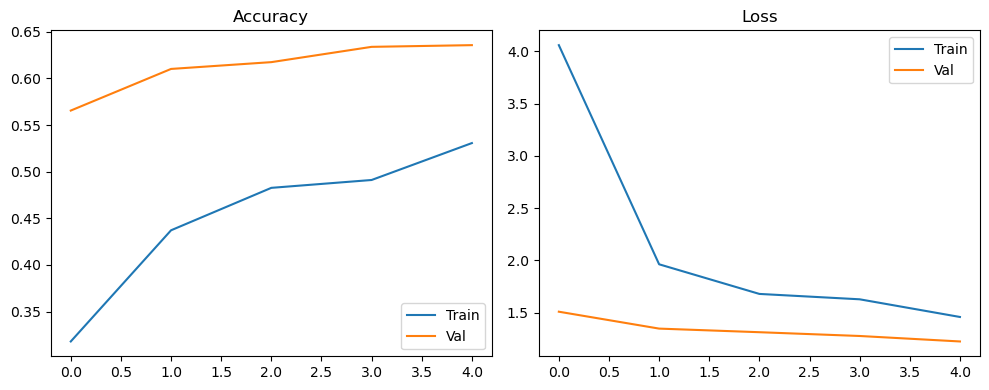

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Config
dataset_dir = r"D:\Ed\DL\Proj\pest"  # CHANGE THIS
img_size = (224, 224)
batch_size = 32
epochs = 5  # Fast

# Load data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Preprocess
preprocess_input = tf.keras.applications.vgg16.preprocess_input

# Model
base_model = VGG16(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_model.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

model.save("vgg16_pest_classifier.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("vgg16_training_plot.png")
plt.show()
